<a href="https://colab.research.google.com/github/beleja05/neuraldata_Amanda/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amanda Belej
*Introduction to Neural Data Analysis*

**03/06/2026**

In [ ]:
#This cell imports the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
#This takes the patch_seq_expanded file and turns it into a pandas dataframe.
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)

Text(0, 0.5, 'Count')

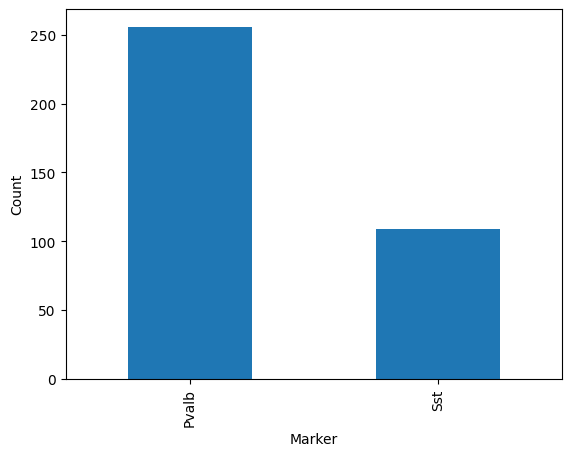

In [ ]:
#This cell makes a bar plot of the number of values in each cell type. It then labels the x and y axis accordingly
patch_seq['Marker'].value_counts().plot.bar()
plt.xlabel('Marker')
plt.ylabel('Count')

<Axes: ylabel='count'>

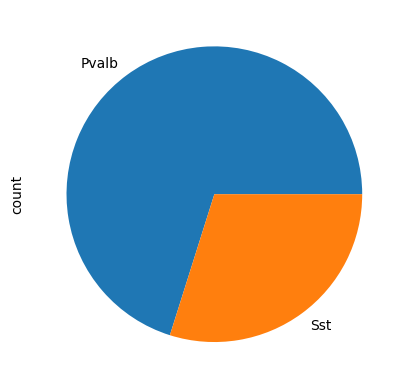

In [ ]:
#This cell plots the same information from above in a pie chart instead of a bar graph.
patch_seq['Marker'].value_counts().plot.pie()

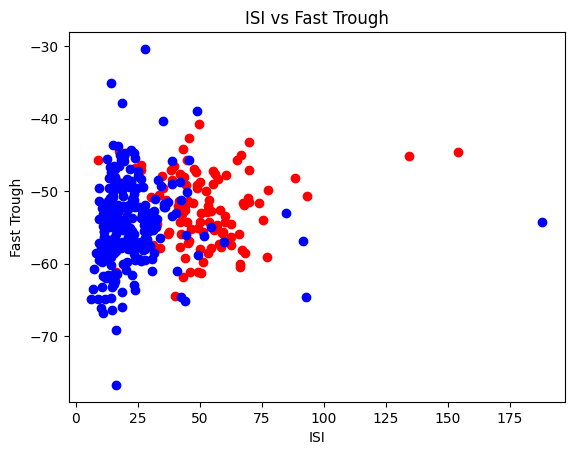

In [ ]:
#This cell makes a scatterplot with ISI on the x-axis and Fast Trough on the y-axis. It first makes a smaller dataset that seperates Pvalb and Sst into their own dataset. It then plots all Pvalb data points in blue and all Sst data in red.
for marker in patch_seq['Marker'].unique():
  small_dataset = patch_seq[patch_seq['Marker'] == marker]
  if marker == 'Pvalb':
    plt.scatter(small_dataset['ISI'], small_dataset['Fast_Trough'], c='blue', label='Pvalb')
  else:
    plt.scatter(small_dataset['ISI'], small_dataset['Fast_Trough'], c='red', label='Sst')
plt.xlabel('ISI')
plt.ylabel('Fast Trough')
plt.title('ISI vs Fast Trough')
plt.show()

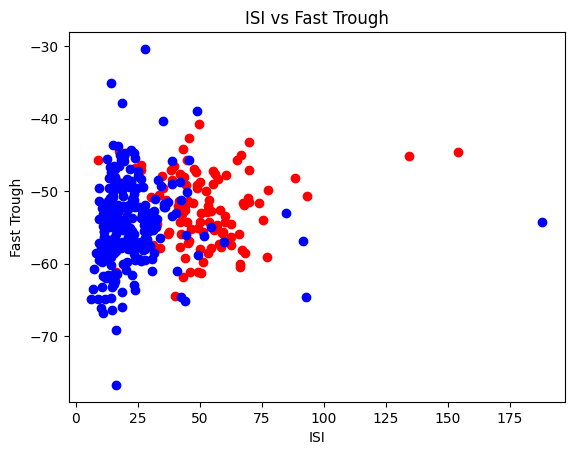

In [ ]:
#This takes the code above and turns it into a function and the calls that function
def pathScatter():
  for marker in patch_seq['Marker'].unique():
    small_dataset = patch_seq[patch_seq['Marker'] == marker]
    if marker == 'Pvalb':
      plt.scatter(small_dataset['ISI'], small_dataset['Fast_Trough'], c='blue', label='Pvalb')
    else:
      plt.scatter(small_dataset['ISI'], small_dataset['Fast_Trough'], c='red', label='Sst')
  plt.xlabel('ISI')
  plt.ylabel('Fast Trough')
  plt.title('ISI vs Fast Trough')
  plt.show()
pathScatter()

In [ ]:
#This cell gives statistics about fast trough seperated by Pvalb and Sst
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The describe method shows that there are more Pvalb neurons than Sst and that there is a wider range of values for fast trough in the Pvalb dataset. In general, the Pvalb neurons have a more negitive undershoot after an action potential than Sst neurons as shown by the means.

In [ ]:
#This checks to see if the fast trough values for each neuron type are skewed in one direction at all.
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


This shows that there isn't much of a skew within the fast troughSst neurons. However, the Pvalb neurons data is skewed in regards to fast trough.

In [ ]:
#This checks to see if the ISI values for each neuron type are skewed in one direction at all.
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Both had huge skewness results. This means that the data of both are very skewed to one side.

In [ ]:
#This cell performs a t-test to compare the fast trough of Sst neurons to those of Pvalb neurons to see if they are statistically significantly different. It also tries to do this which ISI, but fails because values are missing.
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']
fast_t_test = stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])
ISI_t_test = stats.ttest_ind(sst_neurons['ISI'], pvalb_neurons['ISI'])
print("fast results", fast_t_test)
print("ISI results", ISI_t_test)

fast results TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))
ISI results TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


The p-value for the fast trough comparison yielded significant results because it was less than 0.05. ISI doesn't yield a p-value because there are missing values

In [ ]:
#This cell performs a t-test to compare the ISI of Sst neurons to those of Pvalb neurons to see if they are statistically significantly different.
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()
ISI_t_test = stats.ttest_ind(sst, pvalb)
print("ISI results", ISI_t_test)

ISI results TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))


The p-value of the ISI t-test is extremely small, indicating that there is a significant difference in ISI values between Sst and Pvalb neurons.